In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import (
    GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras import mixed_precision

from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, auc,
    cohen_kappa_score, matthews_corrcoef
)
from sklearn.preprocessing import label_binarize

# ── Reproducibility ─────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── Mixed precision (faster GPU training, same accuracy) ──────
mixed_precision.set_global_policy('mixed_float16')

print('TensorFlow :', tf.__version__)
print('GPU        :', tf.config.list_physical_devices('GPU'))

2026-06-24 07:53:13.931189: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782287594.166687      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782287594.240401      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782287594.770909      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782287594.770986      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782287594.770990      58 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Paths & Config

In [2]:
# ── Paths ──────────────────────────────────────────
TRAIN_DIR = "/kaggle/input/datasets/joynob/augmented-dataset2/Step2_Augmented_Dataset/train"
VALID_DIR = "/kaggle/input/datasets/joynob/augmented-dataset2/Step2_Augmented_Dataset/valid"
TEST_DIR  = "/kaggle/input/datasets/joynob/augmented-dataset2/Step2_Augmented_Dataset/test"

# ── Config ──────────────────────────────────────────
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
EPOCHS       = 150
WARMUP_EP    = 5
BASE_LR      = 3e-4
MIN_LR       = 1e-6
NUM_CLASSES  = 4
LABEL_SMOOTH = 0.03

L2           = 1e-4        # same L2 weight as MSRA-CNN

## 3. Data Generators

**DenseNet121 preprocessing note:** Unlike EfficientNetB0 (which has built-in
rescaling layers and expects raw [0,255] pixels), DenseNet121 has NO built-in
rescaling. It was trained using PyTorch-style preprocessing (`mode='torch'`):
pixels normalized to [0,1] then standardized by ImageNet mean/std
([0.485,0.456,0.406] / [0.229,0.224,0.225]).

The correct approach is `preprocessing_function=tf.keras.applications.densenet.preprocess_input`
inside the ImageDataGenerator. This handles the full normalization automatically
from raw [0,255] pixel input — no manual rescale needed or wanted.

In [3]:
# DenseNet121 requires its own preprocess_input (torch-mode normalization).
# DO NOT add rescale=1./255 here — preprocess_input already handles scaling.
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

datagen_train = ImageDataGenerator(preprocessing_function=densenet_preprocess)
datagen_eval  = ImageDataGenerator(preprocessing_function=densenet_preprocess)

train_gen = datagen_train.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', seed=SEED
)
valid_gen = datagen_eval.flow_from_directory(
    VALID_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)
test_gen = datagen_eval.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print('Classes :', CLASS_NAMES)
print(f'Train   : {train_gen.samples}')
print(f'Valid   : {valid_gen.samples}')
print(f'Test    : {test_gen.samples}')

# Sanity check: after DenseNet preprocessing, values are ~[-2.1, +2.6]
_sample_batch, _ = next(train_gen)
print(f'Sample batch pixel range after preprocess_input: [{_sample_batch.min():.3f}, {_sample_batch.max():.3f}]')
print('(Expected roughly [-2.1, 2.6], NOT [0,1] or [0,255])')
train_gen.reset()

Found 26352 images belonging to 4 classes.
Found 1586 images belonging to 4 classes.
Found 1584 images belonging to 4 classes.
Classes : ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Train   : 26352
Valid   : 1586
Test    : 1584
Sample batch pixel range after preprocess_input: [-2.118, 2.640]
(Expected roughly [-2.1, 2.6], NOT [0,1] or [0,255])


## 4. Model — DenseNet121 (Transfer Learning)

ImageNet-pretrained DenseNet121 backbone with the top classification head replaced.
The dense head uses the **exact same layer pattern as MSRA-CNN**:
`Dense(L2-regularized) → BatchNormalization → Activation('relu') → Dropout`,
at the same 512 → 256 → 128 depth with the same dropout rates (0.5 / 0.3 / 0.2)
and the same L2 weight (1e-4).

Two-phase training (same as EfficientNetB0 notebook):
- **Phase 1:** backbone frozen, train only the new head at `BASE_LR = 3e-4`
- **Phase 2:** unfreeze the last 50 DenseNet layers, keep BatchNorm frozen,
  fine-tune at `FT_BASE_LR = 1e-5`

In [4]:
def build_densenet121(input_shape=(224, 224, 3), num_classes=4):
    base_model = DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling=None
    )
    base_model.trainable = False  # Phase 1: frozen backbone

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    # Dense head — exact same pattern as MSRA-CNN:
    # Dense(L2-regularized) → BatchNorm → Activation('relu') → Dropout
    x = Dense(512, kernel_regularizer=tf.keras.regularizers.l2(L2))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.5)(x)

    x = Dense(256, kernel_regularizer=tf.keras.regularizers.l2(L2))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.3)(x)

    x = Dense(128, kernel_regularizer=tf.keras.regularizers.l2(L2))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.2)(x)

    outputs = Dense(num_classes, activation='softmax', dtype='float32')(x)

    model = Model(inputs=base_model.input, outputs=outputs,
                  name='DenseNet121_BrainTumor')
    return model, base_model

model, base_model = build_densenet121(input_shape=IMG_SIZE + (3,),
                                       num_classes=NUM_CLASSES)
model.summary()

I0000 00:00:1782287615.673955      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782287615.680117      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DenseNet121_BrainTumor"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,730,628 (29.49 MB)

 Trainable params: 691,332 (2.64 MB)

 Non-trainable params: 7,039,296 (26.85 MB)

In [5]:
total_params     = model.count_params()
trainable_params = sum(tf.keras.backend.count_params(w)
                       for w in model.trainable_weights)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}  (Phase 1, frozen backbone)')

Total params     : 7,730,628
Trainable params : 691,332  (Phase 1, frozen backbone)


## 5. Warmup-Cosine LR Schedule (identical callback to MSRA-CNN)

In [6]:
class WarmupCosineDecay(tf.keras.callbacks.Callback):
    def __init__(self, total_epochs, warmup_epochs, base_lr, min_lr):
        super().__init__()
        self.total_epochs  = total_epochs
        self.warmup_epochs = warmup_epochs
        self.base_lr       = base_lr
        self.min_lr        = min_lr

    def _get_lr(self, epoch):
        if epoch < self.warmup_epochs:
            return self.base_lr * (epoch + 1) / self.warmup_epochs
        else:
            progress = (epoch - self.warmup_epochs) / (
                        self.total_epochs - self.warmup_epochs)
            cosine   = 0.5 * (1.0 + np.cos(np.pi * progress))
            return self.min_lr + (self.base_lr - self.min_lr) * cosine

    def _set_lr(self, lr):
        opt = self.model.optimizer
        if hasattr(opt, 'inner_optimizer'):   # unwrap LossScaleOptimizer
            opt = opt.inner_optimizer
        if hasattr(opt, 'learning_rate'):
            opt.learning_rate.assign(lr)
        elif hasattr(opt, 'lr'):
            tf.keras.backend.set_value(opt.lr, lr)

    def on_epoch_begin(self, epoch, logs=None):
        self._set_lr(float(self._get_lr(epoch)))

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs['lr'] = float(self._get_lr(epoch))

print('WarmupCosineDecay callback defined.')

WarmupCosineDecay callback defined.


## 6. Phase 1 — Train the Classification Head (frozen backbone)

In [7]:
PHASE1_EPOCHS = 20

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=BASE_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)

phase1_callbacks = [
    WarmupCosineDecay(PHASE1_EPOCHS, min(WARMUP_EP, PHASE1_EPOCHS - 1),
                      BASE_LR, MIN_LR),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=8,
        restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.CSVLogger('phase1_training_log.csv')
]

history_phase1 = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=PHASE1_EPOCHS,
    callbacks=phase1_callbacks,
    verbose=1
)

Epoch 1/20


I0000 00:00:1782287638.899530     151 service.cc:152] XLA service 0x7975dc04f610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782287638.899570     151 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782287638.899573     151 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782287643.398687     151 cuda_dnn.cc:529] Loaded cuDNN version 91002


  2/824 ━━━━━━━━━━━━━━━━━━━━ 44s 55ms/step - accuracy: 0.1875 - loss: 2.1786   

I0000 00:00:1782287662.357134     151 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


824/824 ━━━━━━━━━━━━━━━━━━━━ 260s 265ms/step - accuracy: 0.6353 - loss: 1.0560 - val_accuracy: 0.8115 - val_loss: 0.6697 - lr: 6.0000e-05
Epoch 2/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 108s 131ms/step - accuracy: 0.8129 - loss: 0.6714 - val_accuracy: 0.8663 - val_loss: 0.5314 - lr: 1.2000e-04
Epoch 3/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 105s 127ms/step - accuracy: 0.8586 - loss: 0.5679 - val_accuracy: 0.8827 - val_loss: 0.4935 - lr: 1.8000e-04
Epoch 4/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 108s 131ms/step - accuracy: 0.8849 - loss: 0.5034 - val_accuracy: 0.9180 - val_loss: 0.4341 - lr: 2.4000e-04
Epoch 5/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 107s 129ms/step - accuracy: 0.9013 - loss: 0.4663 - val_accuracy: 0.9306 - val_loss: 0.4003 - lr: 3.0000e-04
Epoch 6/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 110s 134ms/step - accuracy: 0.9150 - loss: 0.4319 - val_accuracy: 0.9338 - val_loss: 0.3861 - lr: 3.0000e-04
Epoch 7/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 108s 131ms/step - accuracy: 0.9257 - loss: 0.4074 - val_accuracy: 0.9414 - va

## 7. Phase 2 — Unfreeze & Fine-Tune

Same strategy as EfficientNetB0 notebook (proven working):
- Unfreeze last 50 DenseNet layers (the dense blocks closest to the output)
- Keep BatchNorm layers frozen throughout (protects pretrained ImageNet statistics)
- Fine-tune LR = `1e-5` (MSRA-CNN's proven `3e-4` scaled down 30x for pretrained weights)
- Same WarmupCosineDecay, EarlyStopping(patience=17), ModelCheckpoint, CSVLogger

In [8]:
base_model.trainable = True

# Keep BatchNorm layers frozen — protects pretrained statistics
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Unfreeze the last 50 layers of the DenseNet backbone
UNFREEZE_LAST_N = 50
for layer in base_model.layers[:-UNFREEZE_LAST_N]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Backbone layers unfrozen: {trainable_count} / {len(base_model.layers)}')
print('(BatchNorm layers forced frozen regardless of position)')

FT_BASE_LR = 1e-5   # MSRA-CNN's proven 3e-4 scaled down 30x for fine-tuning
FT_EPOCHS  = EPOCHS

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FT_BASE_LR),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH),
    metrics=['accuracy']
)

callbacks = [
    WarmupCosineDecay(FT_EPOCHS, WARMUP_EP, FT_BASE_LR, MIN_LR),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=17,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_densenet121.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger('training_log.csv')
]

print('Phase 2 compile done. Backbone trainable:', base_model.trainable)
print(f'Fine-tuning LR: {FT_BASE_LR}')

Backbone layers unfrozen: 36 / 427
(BatchNorm layers forced frozen regardless of position)
Phase 2 compile done. Backbone trainable: True
Fine-tuning LR: 1e-05


In [9]:
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=FT_EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150
824/824 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9751 - loss: 0.2832
Epoch 1: val_accuracy improved from None to 0.96658, saving model to best_densenet121.keras

Epoch 1: finished saving model to best_densenet121.keras
824/824 ━━━━━━━━━━━━━━━━━━━━ 179s 171ms/step - accuracy: 0.9744 - loss: 0.2829 - val_accuracy: 0.9666 - val_loss: 0.3031 - lr: 2.0000e-06
Epoch 2/150
824/824 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.9738 - loss: 0.2837
Epoch 2: val_accuracy improved from 0.96658 to 0.96847, saving model to best_densenet121.keras

Epoch 2: finished saving model to best_densenet121.keras
824/824 ━━━━━━━━━━━━━━━━━━━━ 109s 132ms/step - accuracy: 0.9743 - loss: 0.2832 - val_accuracy: 0.9685 - val_loss: 0.2999 - lr: 4.0000e-06
Epoch 3/150
824/824 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9753 - loss: 0.2816
Epoch 3: val_accuracy did not improve from 0.96847
824/824 ━━━━━━━━━━━━━━━━━━━━ 105s 127ms/step - accuracy: 0.9753 - loss: 0.2800 - val_accuracy: 0.9666 -

## 8. Training Curves (Accuracy / Loss / LR)

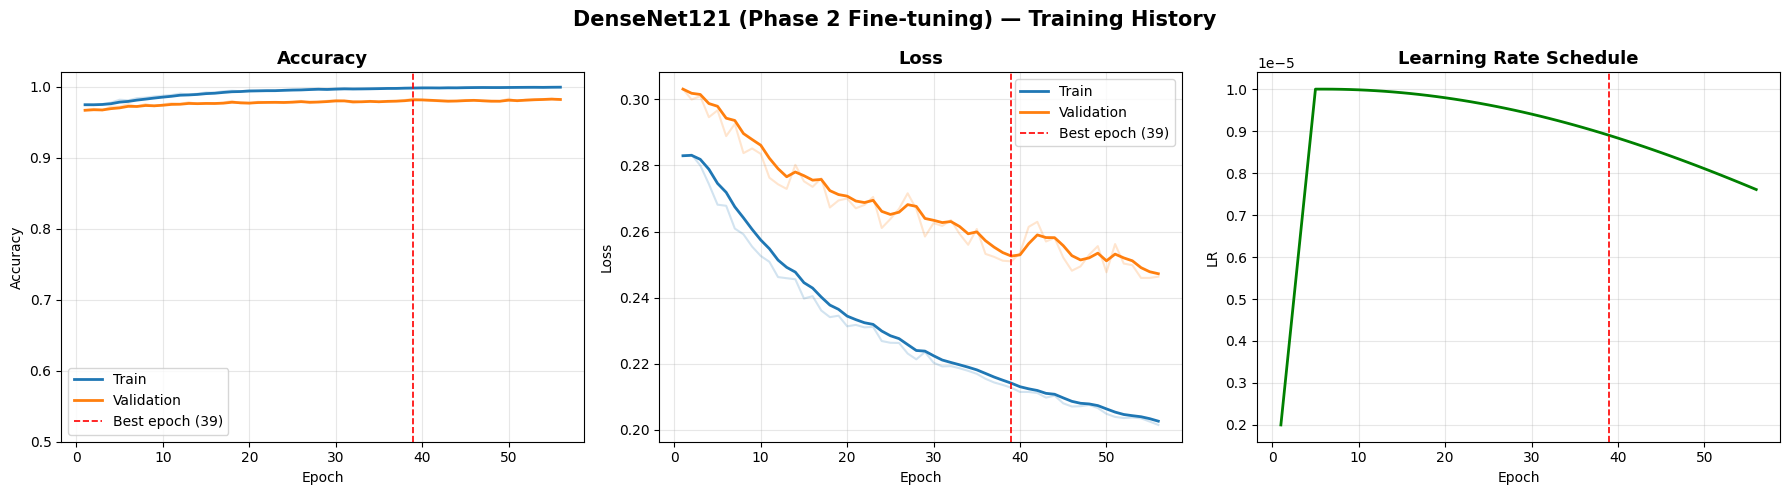

Best Epoch    : 39
Best Val Acc  : 0.9830
Best Val Loss : 0.2460


In [10]:
def ema_smooth(values, weight=0.6):
    """Exponential moving average smoothing — same formula as MSRA-CNN notebook."""
    smoothed, last = [], values[0]
    for v in values:
        last = last * weight + v * (1 - weight)
        smoothed.append(last)
    return smoothed


h = history.history
ep           = range(1, len(h['accuracy']) + 1)
best_ep      = np.argmax(h['val_accuracy']) + 1
best_val_acc = max(h['val_accuracy'])
best_val_loss= min(h['val_loss'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
TC, VC = '#1f77b4', '#ff7f0e'

# ── Accuracy ─────────────────────────────────────────
ax = axes[0]
ax.plot(ep, h['accuracy'],     color=TC, alpha=0.2)
ax.plot(ep, ema_smooth(h['accuracy']),
        color=TC, lw=2, label='Train')
ax.plot(ep, h['val_accuracy'], color=VC, alpha=0.2)
ax.plot(ep, ema_smooth(h['val_accuracy']),
        color=VC, lw=2, label='Validation')
ax.axvline(best_ep, color='red', ls='--', lw=1.2,
           label=f'Best epoch ({best_ep})')
ax.set_title('Accuracy', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.set_ylim([0.5, 1.02]); ax.legend(); ax.grid(alpha=0.3)

# ── Loss ──────────────────────────────────────────
ax = axes[1]
ax.plot(ep, h['loss'],     color=TC, alpha=0.2)
ax.plot(ep, ema_smooth(h['loss']),
        color=TC, lw=2, label='Train')
ax.plot(ep, h['val_loss'], color=VC, alpha=0.2)
ax.plot(ep, ema_smooth(h['val_loss']),
        color=VC, lw=2, label='Validation')
ax.axvline(best_ep, color='red', ls='--', lw=1.2,
           label=f'Best epoch ({best_ep})')
ax.set_title('Loss', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# ── LR Schedule ────────────────────────────────────────
ax  = axes[2]
lrs = []
for e in range(len(h['accuracy'])):
    if e < WARMUP_EP:
        lrs.append(FT_BASE_LR * (e + 1) / WARMUP_EP)
    else:
        prog = (e - WARMUP_EP) / (FT_EPOCHS - WARMUP_EP)
        lrs.append(MIN_LR + (FT_BASE_LR - MIN_LR) * 0.5 *
                   (1 + np.cos(np.pi * prog)))
ax.plot(ep, lrs, color='green', lw=2)
ax.axvline(best_ep, color='red', ls='--', lw=1.2)
ax.set_title('Learning Rate Schedule', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
ax.grid(alpha=0.3)

plt.suptitle('DenseNet121 (Phase 2 Fine-tuning) — Training History',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_densenet121.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'Best Epoch    : {best_ep}')
print(f'Best Val Acc  : {best_val_acc:.4f}')
print(f'Best Val Loss : {best_val_loss:.4f}')

## 9. Test Set Predictions

In [11]:
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f'Test Loss : {test_loss:.4f}')
print(f'Test Acc  : {test_acc:.4f}')

test_gen.reset()
y_pred_prob    = model.predict(test_gen, verbose=1)
y_pred_classes = np.argmax(y_pred_prob, axis=1)
y_true         = test_gen.classes

Test Loss : 0.2491
Test Acc  : 0.9811
50/50 ━━━━━━━━━━━━━━━━━━━━ 31s 399ms/step


## 10. Quantitative Evaluation — identical metric suite to MSRA-CNN

In [12]:
def compute_metrics(y_true, y_pred, label=''):
    acc   = accuracy_score(y_true, y_pred)
    pre   = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec   = recall_score(y_true, y_pred,    average='weighted', zero_division=0)
    f1    = f1_score(y_true, y_pred,        average='weighted', zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    mcc   = matthews_corrcoef(y_true, y_pred)

    print(f'\n── {label} ────────────────────')
    print(f'  Accuracy        : {acc:.4f}')
    print(f'  Precision       : {pre:.4f}')
    print(f'  Recall          : {rec:.4f}')
    print(f'  F1 Score        : {f1:.4f}')
    print(f'  Cohen Kappa (κ) : {kappa:.4f}')
    print(f'  MCC             : {mcc:.4f}')
    return dict(Accuracy=acc, Precision=pre, Recall=rec,
                F1=f1, Kappa=kappa, MCC=mcc)

m_densenet = compute_metrics(y_true, y_pred_classes, 'DenseNet121')

print('\n── Per-class Report ────────────────')
print(classification_report(
    y_true, y_pred_classes, target_names=CLASS_NAMES
))


── DenseNet121 ────────────────────
  Accuracy        : 0.9811
  Precision       : 0.9812
  Recall          : 0.9811
  F1 Score        : 0.9811
  Cohen Kappa (κ) : 0.9741
  MCC             : 0.9742

── Per-class Report ────────────────
              precision    recall  f1-score   support

      glioma       0.99      0.97      0.98       563
  meningioma       0.96      0.97      0.96       351
    no_tumor       0.99      1.00      1.00       264
   pituitary       0.98      0.99      0.99       406

    accuracy                           0.98      1584
   macro avg       0.98      0.98      0.98      1584
weighted avg       0.98      0.98      0.98      1584



## 11. Confusion Matrix

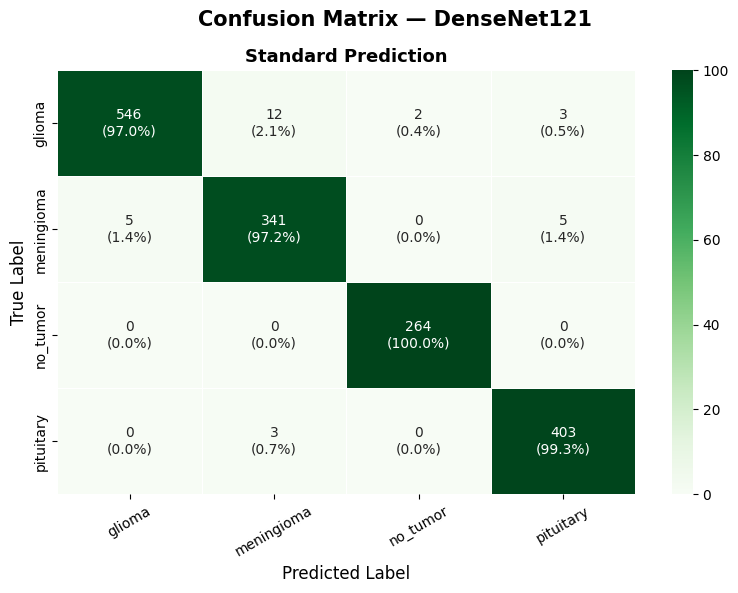

In [13]:
fig, ax = plt.subplots(figsize=(8, 6))

cm     = confusion_matrix(y_true, y_pred_classes)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

annot = np.array([
    [f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)'
     for j in range(len(CLASS_NAMES))]
    for i in range(len(CLASS_NAMES))
])

sns.heatmap(
    cm_pct, annot=annot, fmt='', cmap='Greens',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, vmin=0, vmax=100,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 10}
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Standard Prediction', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrix — DenseNet121', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_densenet121.png', dpi=300, bbox_inches='tight')
plt.show()

## 12. Multi-class ROC Curves

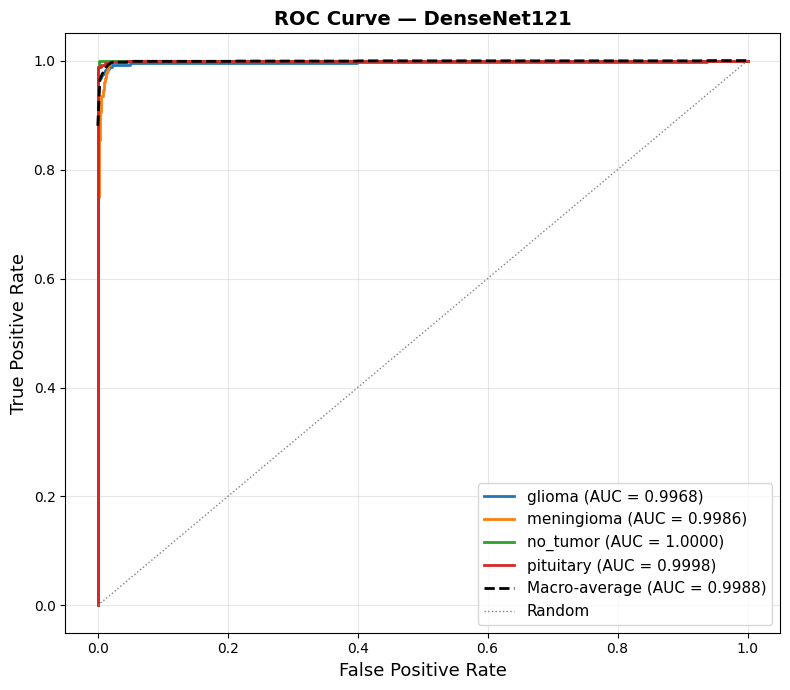

Per-class AUC : {'glioma': '0.9968', 'meningioma': '0.9986', 'no_tumor': '1.0000', 'pituitary': '0.9998'}
Macro AUC     : 0.9988


In [14]:
n_classes = len(CLASS_NAMES)
y_bin     = label_binarize(y_true, classes=list(range(n_classes)))
colors    = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

mean_fpr = np.linspace(0, 1, 300)
tprs, roc_aucs = [], []

fig, ax = plt.subplots(figsize=(8, 7))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_pred_prob[:, i])
    roc_auc     = auc(fpr, tpr)
    roc_aucs.append(roc_auc)
    tprs.append(np.interp(mean_fpr, fpr, tpr))
    ax.plot(fpr, tpr, color=colors[i], lw=2,
            label=f'{CLASS_NAMES[i]} (AUC = {roc_auc:.4f})')

mean_tpr     = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
macro_auc    = auc(mean_fpr, mean_tpr)
ax.plot(mean_fpr, mean_tpr, 'k--', lw=2,
        label=f'Macro-average (AUC = {macro_auc:.4f})')
ax.plot([0,1],[0,1], color='gray', lw=1, ls=':', label='Random')

ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate',  fontsize=13)
ax.set_title('ROC Curve — DenseNet121', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_densenet121.png', dpi=300, bbox_inches='tight')
plt.show()

print('Per-class AUC :', {c: f'{a:.4f}' for c, a in zip(CLASS_NAMES, roc_aucs)})
print(f'Macro AUC     : {macro_auc:.4f}')

## 13. Grad-CAM

**DenseNet121 Grad-CAM target layer:** `conv5_block16_2_conv`
This is the last convolutional layer inside the final dense block (dense_block4),
immediately before the final BatchNorm/ReLU/GAP — the deepest feature map
in the network, equivalent in role to `conv2d_47` in MSRA-CNN and `top_conv`
in EfficientNetB0.

The Grad-CAM function is identical to both previous notebooks.
**No /255.0 rescaling** of the image array before feeding to the model —
`densenet_preprocess` handles normalization inside the function.

In [15]:
def run_gradcam(img_path, model, last_conv_layer_name, class_names, figsize=(18, 6)):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224, 224))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    # Apply DenseNet121's own preprocessing (torch-mode normalization)
    # same as what the data generators use — must match exactly
    img_array = tf.keras.applications.densenet.preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array, verbose=0)
    pred_class = np.argmax(preds[0])
    print('Predicted Class :', class_names[pred_class])
    print('Confidence      :', round(np.max(preds[0]) * 100, 2), '%')

    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, pred_class]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    if tf.reduce_max(heatmap) > 0:
        heatmap = heatmap / tf.reduce_max(heatmap)
    heatmap = np.squeeze(heatmap.numpy()).astype(np.float32)

    original = cv2.imread(img_path)
    original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

    heatmap = cv2.resize(heatmap, (original.shape[1], original.shape[0]),
                         interpolation=cv2.INTER_LINEAR)
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(original, 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=figsize)
    plt.subplot(1, 3, 1); plt.imshow(original);   plt.title('Original MRI');    plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(heatmap, cmap='jet'); plt.title('Grad-CAM Heatmap'); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(overlay);    plt.title(f'Prediction: {class_names[pred_class]}'); plt.axis('off')
    plt.tight_layout()
    plt.show()

# DenseNet121 Grad-CAM target layer — last conv in dense_block4
LAST_CONV_LAYER = 'conv5_block16_2_conv'
CLASS_NAMES_GC  = ['glioma', 'meningioma', 'no_tumor', 'pituitary']

In [16]:
# Verify the target layer actually exists in this model
conv_layer_names = [l.name for l in model.layers if 'conv' in l.name.lower()]
print('Last 5 conv-related layers:', conv_layer_names[-5:])
assert LAST_CONV_LAYER in [l.name for l in model.layers], (
    f"'{LAST_CONV_LAYER}' not found. "
    f"Run `for l in model.layers: print(l.name)` and update LAST_CONV_LAYER."
)
print(f"Confirmed: '{LAST_CONV_LAYER}' exists in the model.")

Last 5 conv-related layers: ['conv5_block16_1_conv', 'conv5_block16_1_bn', 'conv5_block16_1_relu', 'conv5_block16_2_conv', 'conv5_block16_concat']
Confirmed: 'conv5_block16_2_conv' exists in the model.


Predicted Class : meningioma
Confidence      : 97.86 %


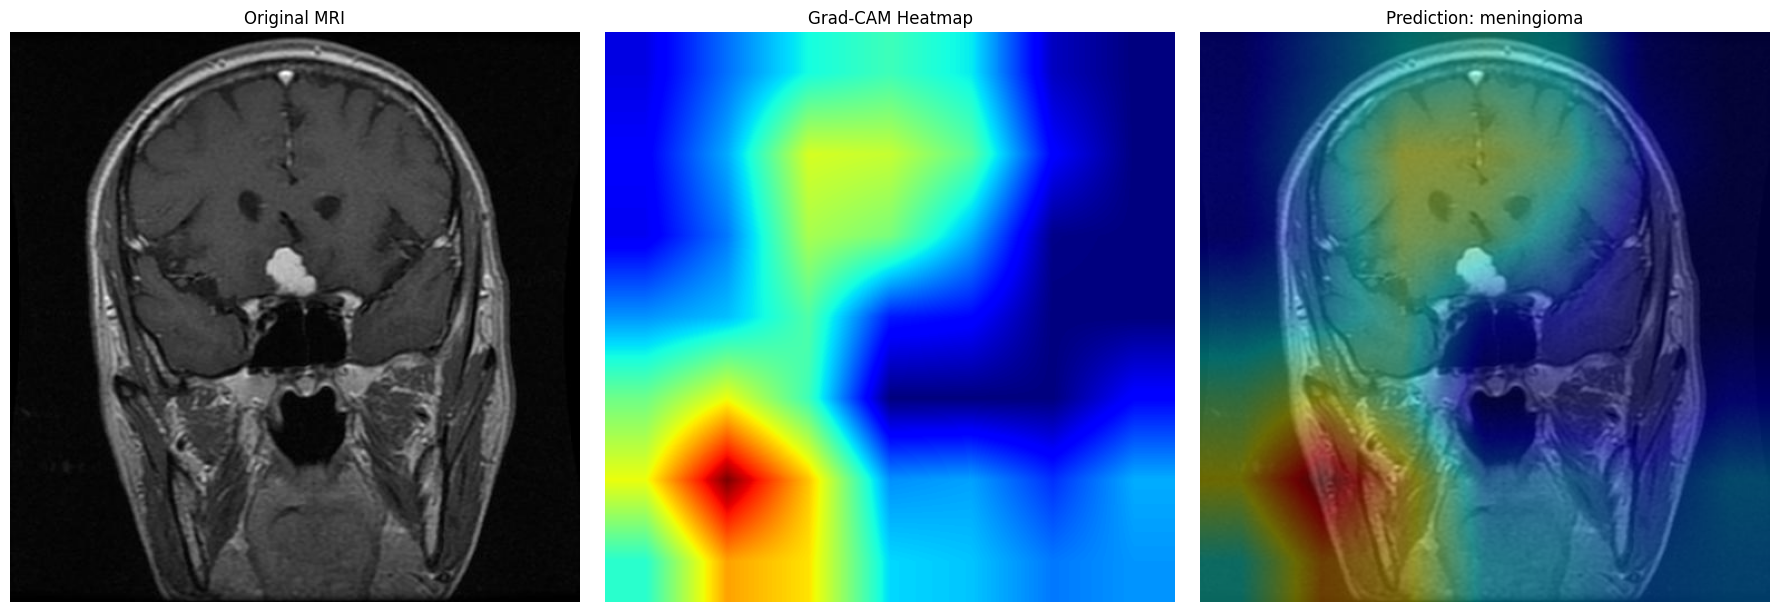

In [18]:
# Meningioma sample (same image as MSRA-CNN and EfficientNetB0 notebooks)
IMG_PATH = "/kaggle/input/datasets/joynob/augmented-dataset2/Step2_Augmented_Dataset/test/meningioma/meningioma1001.jpg"
run_gradcam(IMG_PATH, model, LAST_CONV_LAYER, CLASS_NAMES_GC)

Predicted Class : glioma
Confidence      : 98.58 %


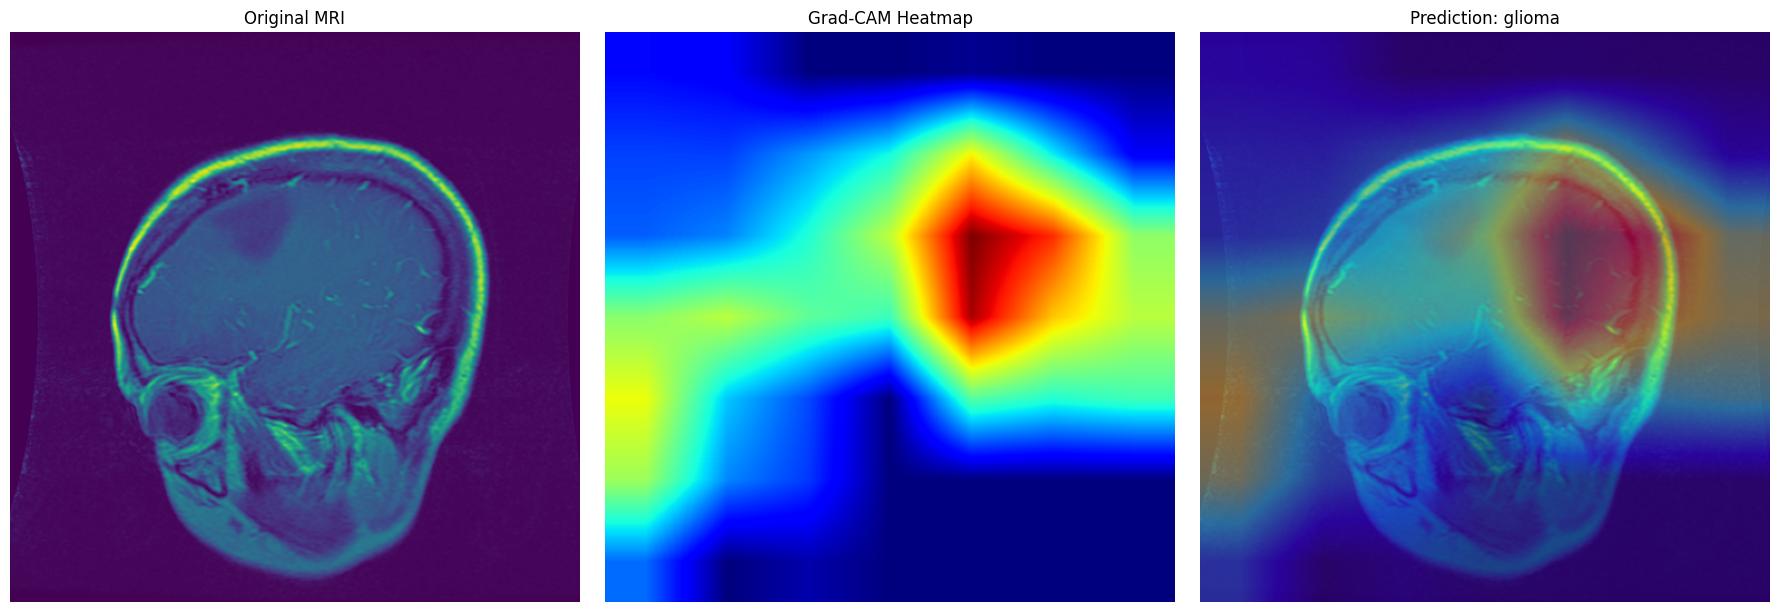

In [20]:
# Glioma sample (same image as MSRA-CNN and EfficientNetB0 notebooks)
IMG_PATH = "/kaggle/input/datasets/joynob/augmented-dataset2/Step2_Augmented_Dataset/test/glioma/glioma101.png"
run_gradcam(IMG_PATH, model, LAST_CONV_LAYER, CLASS_NAMES_GC)

Predicted Class : pituitary
Confidence      : 98.52 %


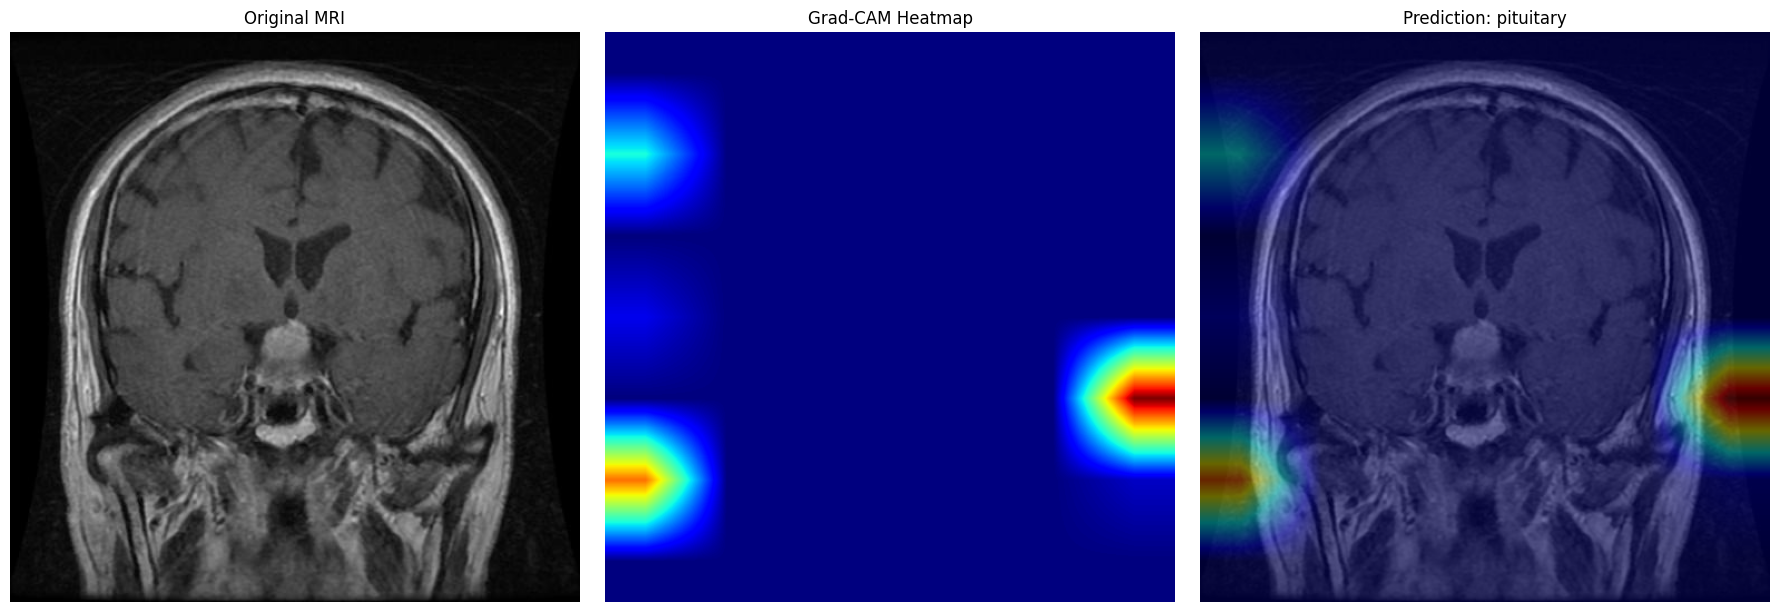

In [22]:
# Pituitary sample (same image as MSRA-CNN and EfficientNetB0 notebooks)
IMG_PATH = "/kaggle/input/datasets/joynob/augmented-dataset2/Step2_Augmented_Dataset/test/pituitary/pituitary1025.jpg"
run_gradcam(IMG_PATH, model, LAST_CONV_LAYER, CLASS_NAMES_GC)

## 14. Save Final Model

In [23]:
model.save('densenet121_braintumor_final.keras')
print('Model saved: densenet121_braintumor_final.keras')
print('\nFinal params:')
print(f'  Total     : {model.count_params():,}')
print(f'\nFinal test metrics (DenseNet121):')
for k, v in m_densenet.items():
    print(f'  {k:12s}: {v:.4f}')
print(f'  Macro AUC   : {macro_auc:.4f}')

Model saved: densenet121_braintumor_final.keras

Final params:
  Total     : 7,730,628

Final test metrics (DenseNet121):
  Accuracy    : 0.9811
  Precision   : 0.9812
  Recall      : 0.9811
  F1          : 0.9811
  Kappa       : 0.9741
  MCC         : 0.9742
  Macro AUC   : 0.9988
